
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [14]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



# **Desarrollo del Laboratorio**

In [4]:
df

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# **Punto 1**

In [5]:
prof_picos = df['longitud_pico (mm)']
max_prof_pico=df['longitud_pico (mm)'].max()
min_prof_pico=df['longitud_pico (mm)'].min()
print(f'La profundidad máxima del pico es: {max_prof_pico}')
print(f'La profundidad mínima del pico es: {min_prof_pico}')

La profundidad máxima del pico es: 59.6
La profundidad mínima del pico es: 32.1


# **Punto 2**

In [7]:
ind_pinguino = np.argmax(df['masa_corporal (g)'])
ping_gordo = df.loc[ind_pinguino]
print(f'La especie, isla y género del pinguino más gordo es: {ping_gordo}')

La especie, isla y género del pinguino más gordo es: especie                  Gentoo
isla                     Biscoe
longitud_pico (mm)         49.2
profundidad_pico (mm)      15.2
longitud_aleta (mm)       221.0
masa_corporal (g)        6300.0
genero                     Male
Name: 231, dtype: object


# **Punto 3**

In [16]:
machos_Gen = df[np.logical_and(df['genero'] == 'Male', df['especie'] != 'Gentoo')]
media_masa = machos_Gen['masa_corporal (g)'].mean()
print(f'La masa corporal media de los pingüinos machos que no son de la especie Gentoo es: {media_masa:.2f} gramos')

La masa corporal media de los pingüinos machos que no son de la especie Gentoo es: 4010.28 gramos


# **Punto 4**

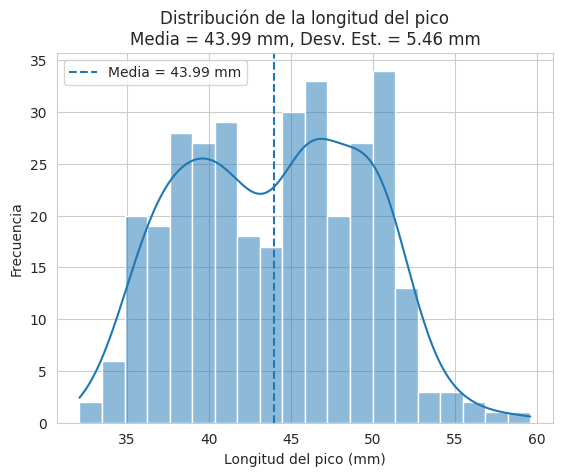

In [15]:
longitud_pico = df["longitud_pico (mm)"]


media = np.mean(longitud_pico)
desv = np.std(longitud_pico)

sns.set_style("whitegrid")
sns.histplot(longitud_pico, bins=20, kde=True)
plt.axvline(media, linestyle="--", label=f"Media = {media:.2f} mm")
plt.title(f"Distribución de la longitud del pico\nMedia = {media:.2f} mm, Desv. Est. = {desv:.2f} mm")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# **Punto 5**

In [18]:
frecuencia_especies = df["especie"].value_counts()
frecuencia_islas = df["isla"].value_counts()
print("Frecuencia de especies:")
print(frecuencia_especies)
print("\nFrecuencia de islas:")
print(frecuencia_islas)

Frecuencia de especies:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Frecuencia de islas:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64


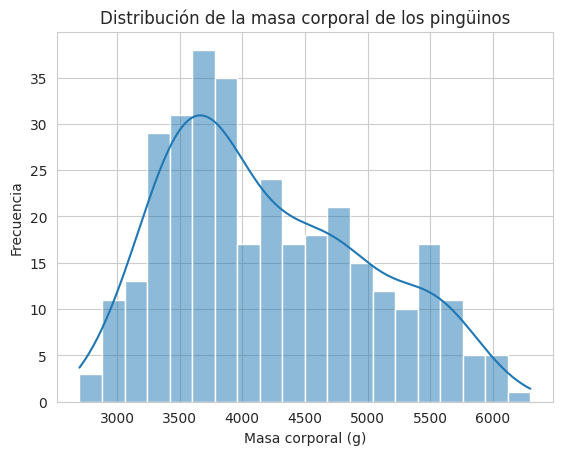

In [19]:
masa = df["masa_corporal (g)"]
sns.set_style("whitegrid")

sns.histplot(masa, bins=20, kde=True)

plt.title("Distribución de la masa corporal de los pingüinos")
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")

plt.show()